In [1]:
# ================================
# Environment Configuration
# ================================

import os
import warnings

warnings.filterwarnings("ignore")

SEED = 42

import numpy as np
import pandas as pd

np.random.seed(SEED)

print("Environment initialized successfully")

Environment initialized successfully


In [2]:
# Kaggle installation

!pip install -q \
xgboost \
catboost \
lightgbm \
boruta \
shap \
interpret \
lime \
optuna \
scikit-optimize \
imbalanced-learn \
SALib \
tabpfn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 52.8 MB/s eta 0:00:0000:01:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 83.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 92.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 96.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 20.2 MB/s eta 0:00:00


In [3]:
# ================================
# Core Imports
# ================================


# Data handling
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Statistics
from scipy import stats


# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import LabelEncoder


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


print("All core libraries imported")

All core libraries imported


In [4]:
# =====================================
# Automatically find dataset files
# =====================================


import os


dataset_path = "/kaggle/input/datasets/mansoordaku/ckdisease"


for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root,file))

/kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv


In [5]:
# =====================================
# Load CSV Dataset
# =====================================


csv_files=[]


for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(
                os.path.join(root,file)
            )


assert len(csv_files)>0, "CSV file not found"


data=pd.read_csv(csv_files[0])


print(
    "Dataset Loaded Successfully"
)


data.head()

Dataset Loaded Successfully


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
print("Dataset Shape:")
print(data.shape)

Dataset Shape:
(400, 26)


In [7]:
print("Dataset Columns:")

for i,col in enumerate(data.columns):
    print(i,col)

Dataset Columns:
0 id
1 age
2 bp
3 sg
4 al
5 su
6 rbc
7 pc
8 pcc
9 ba
10 bgr
11 bu
12 sc
13 sod
14 pot
15 hemo
16 pcv
17 wc
18 rc
19 htn
20 dm
21 cad
22 appet
23 pe
24 ane
25 classification


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [9]:
missing_report=pd.DataFrame({

    "Missing Count":
    data.isnull().sum(),

    "Missing Percentage":
    data.isnull().mean()*100

})


missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
rbc,152,38.00
rc,130,32.50
wc,105,26.25
pot,88,22.00
sod,87,21.75
pcv,70,17.50
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


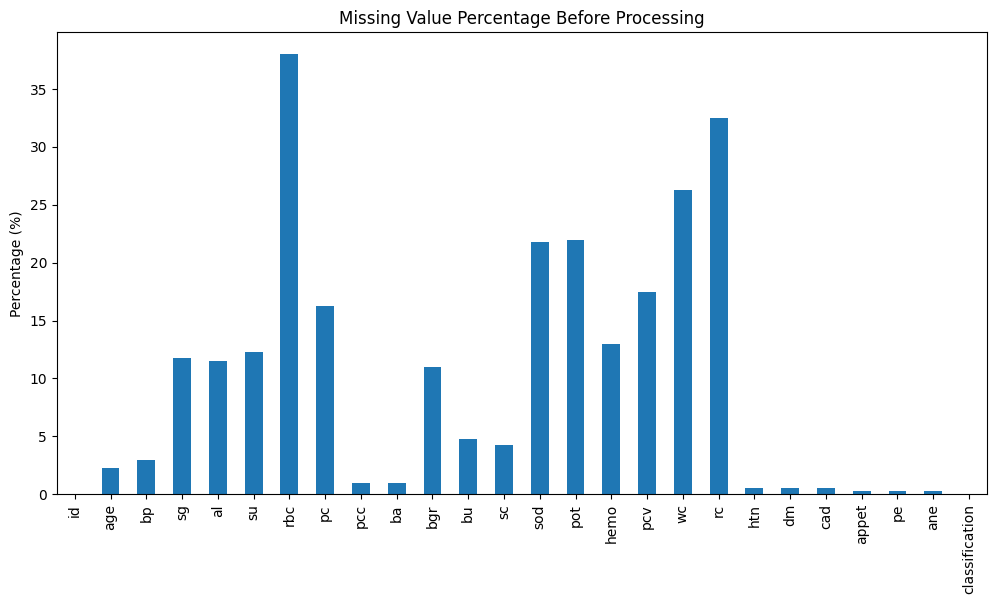

In [10]:
plt.figure(figsize=(12,6))

missing_report["Missing Percentage"].plot(
    kind="bar"
)

plt.title(
    "Missing Value Percentage Before Processing"
)

plt.ylabel(
    "Percentage (%)"
)

plt.xticks(rotation=90)

plt.show()

In [11]:
data.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [12]:
target_column="classification"


print(
    data[target_column]
    .value_counts()
)

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


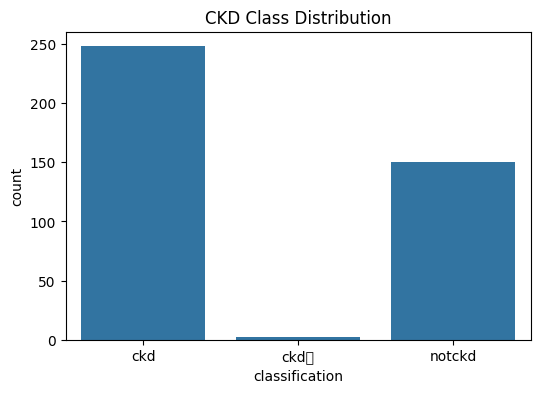

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=data[target_column]
)

plt.title(
    "CKD Class Distribution"
)

plt.show()

In [14]:
data.describe(
    include="all"
).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,400.0,NaN,NaN,NaN,199.5,115.614301,0.0,99.75,199.5,299.25,399.0
age,391.0,NaN,NaN,NaN,51.483376,17.169714,2.0,42.0,55.0,64.5,90.0
bp,388.0,NaN,NaN,NaN,76.469072,13.683637,50.0,70.0,80.0,80.0,180.0
sg,353.0,NaN,NaN,NaN,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,NaN,NaN,NaN,1.016949,1.352679,0.0,0.0,0.0,2.0,5.0
su,351.0,NaN,NaN,NaN,0.450142,1.099191,0.0,0.0,0.0,0.0,5.0
rbc,248,2,normal,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pc,335,2,normal,259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pcc,396,2,notpresent,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ba,396,2,notpresent,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Remove unnecessary index column if present


drop_columns=[]


for col in data.columns:

    if "Unnamed" in str(col):
        drop_columns.append(col)



data=data.drop(
    columns=drop_columns
)


print(
    "Removed:",
    drop_columns
)

Removed: []


In [16]:
# Clean column names

data.columns = (
    data.columns
    .str.strip()
    .str.lower()
)


data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [17]:
# Check target values

data["classification"].unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [18]:
# Convert target labels


data["classification"] = (
    data["classification"]
    .replace(
        {
            "ckd":1,
            "notckd":0,
            "ckd\t":1,
            "notckd\t":0
        }
    )
)


data["classification"].value_counts()

classification
1    250
0    150
Name: count, dtype: int64

In [19]:
# =====================================
# Separate Features and Target
# =====================================


X=data.drop(
    "classification",
    axis=1
)


y=data["classification"]



print(
    X.shape,
    y.shape
)

(400, 25) (400,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y
)



print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Training: (320, 25)
Testing: (80, 25)


In [21]:
print(
"Training distribution"
)

print(
y_train.value_counts(normalize=True)
)


print(
"\nTesting distribution"
)

print(
y_test.value_counts(normalize=True)
)

Training distribution
classification
1    0.625
0    0.375
Name: proportion, dtype: float64

Testing distribution
classification
1    0.625
0    0.375
Name: proportion, dtype: float64


In [22]:
# =====================================
# Identify feature types
# =====================================


categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()



print(
    "Categorical Features:"
)

print(categorical_features)



print(
    "\nNumerical Features:"
)

print(numerical_features)

Categorical Features:
['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

Numerical Features:
['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [23]:
from sklearn.preprocessing import LabelEncoder

# Copy datasets

X_train_encoded = X_train.copy()

X_test_encoded = X_test.copy()


# Store encoders

label_encoders={}


for col in categorical_features:

    encoder=LabelEncoder()


    # Handle missing values temporarily
    X_train_encoded[col] = (
        X_train_encoded[col]
        .astype(str)
    )


    X_test_encoded[col] = (
        X_test_encoded[col]
        .astype(str)
    )


    # Add unseen test categories into encoder classes
    all_categories = (
        list(X_train_encoded[col].unique()) +
        list(
            set(X_test_encoded[col].unique())
            - set(X_train_encoded[col].unique())
        )
    )

    encoder.fit(all_categories)


    X_train_encoded[col] = (
        encoder.transform(
            X_train_encoded[col]
        )
    )


    X_test_encoded[col] = (
        encoder.transform(
            X_test_encoded[col]
        )
    )


    label_encoders[col]=encoder


print(
    "Categorical encoding completed"
)

Categorical encoding completed


In [24]:
X_train_encoded.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
108,108,45.0,80.0,1.015,0.0,0.0,1,0,1,1,...,11.8,25,3,23,1,4,2,0,1,1
210,210,59.0,100.0,1.015,4.0,2.0,2,2,1,1,...,7.3,8,90,19,2,5,3,0,1,2
137,137,45.0,60.0,1.010,2.0,0.0,2,0,2,1,...,10.0,17,84,49,2,5,2,0,1,1
148,148,69.0,60.0,NaN,NaN,NaN,1,1,1,1,...,NaN,44,92,49,2,4,2,2,1,1
246,246,48.0,110.0,1.015,3.0,0.0,0,2,2,1,...,8.6,14,46,4,2,4,3,0,1,2


In [25]:
missing_train_before = (
    X_train_encoded
    .isnull()
    .sum()
)


missing_train_before.sort_values(
    ascending=False
)

pot      76
sod      75
hemo     43
su       42
sg       41
al       40
bgr      38
bu       19
sc       16
bp       11
age       8
rbc       0
id        0
pcc       0
pc        0
ba        0
pcv       0
wc        0
rc        0
htn       0
dm        0
cad       0
appet     0
pe        0
ane       0
dtype: int64

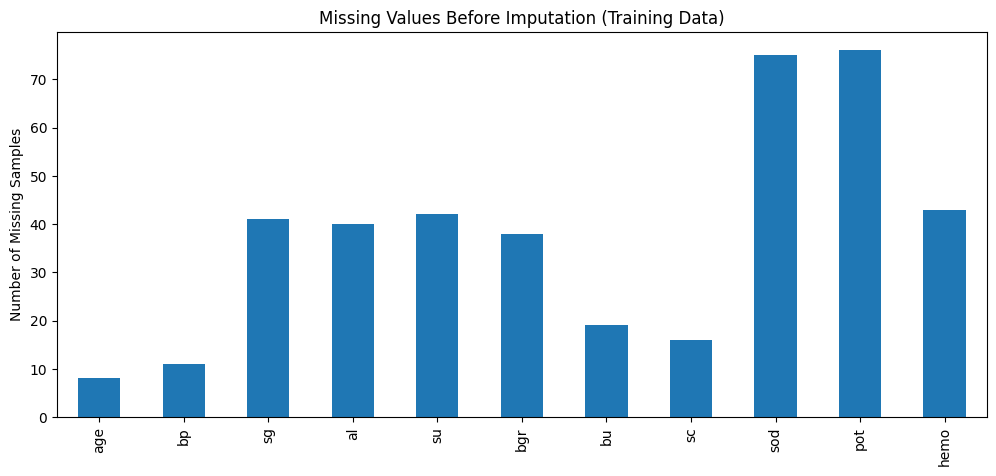

In [26]:
plt.figure(figsize=(12,5))


missing_train_before[
    missing_train_before>0
].plot(
    kind="bar"
)


plt.title(
    "Missing Values Before Imputation (Training Data)"
)


plt.ylabel(
    "Number of Missing Samples"
)


plt.xticks(
    rotation=90
)


plt.show()

In [27]:
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import IterativeImputer

from sklearn.ensemble import ExtraTreesRegressor

# =====================================
# Iterative Imputer
# ExtraTrees Estimator
# =====================================


imputer = IterativeImputer(

    estimator=ExtraTreesRegressor(

        n_estimators=200,

        random_state=SEED,

        n_jobs=-1
    ),

    max_iter=20,

    random_state=SEED

)



# Fit only training data

X_train_imputed = imputer.fit_transform(
    X_train_encoded
)


# Transform test data

X_test_imputed = imputer.transform(
    X_test_encoded
)



print(
    "Imputation Completed"
)


X_train_imputed = pd.DataFrame(

    X_train_imputed,

    columns=X_train_encoded.columns,

    index=X_train_encoded.index

)


X_test_imputed = pd.DataFrame(

    X_test_imputed,

    columns=X_test_encoded.columns,

    index=X_test_encoded.index

)



X_train_imputed.head()

Imputation Completed


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
108,108.0,45.0,80.0,1.01500,0.00,0.000,1.0,0.0,1.0,1.0,...,11.800,25.0,3.0,23.0,1.0,4.0,2.0,0.0,1.0,1.0
210,210.0,59.0,100.0,1.01500,4.00,2.000,2.0,2.0,1.0,1.0,...,7.300,8.0,90.0,19.0,2.0,5.0,3.0,0.0,1.0,2.0
137,137.0,45.0,60.0,1.01000,2.00,0.000,2.0,0.0,2.0,1.0,...,10.000,17.0,84.0,49.0,2.0,5.0,2.0,0.0,1.0,1.0
148,148.0,69.0,60.0,1.01575,2.03,0.585,1.0,1.0,1.0,1.0,...,11.285,44.0,92.0,49.0,2.0,4.0,2.0,2.0,1.0,1.0
246,246.0,48.0,110.0,1.01500,3.00,0.000,0.0,2.0,2.0,1.0,...,8.600,14.0,46.0,4.0,2.0,4.0,3.0,0.0,1.0,2.0


In [28]:
missing_after = (
    X_train_imputed
    .isnull()
    .sum()
)


print(
missing_after.sum()
)

0


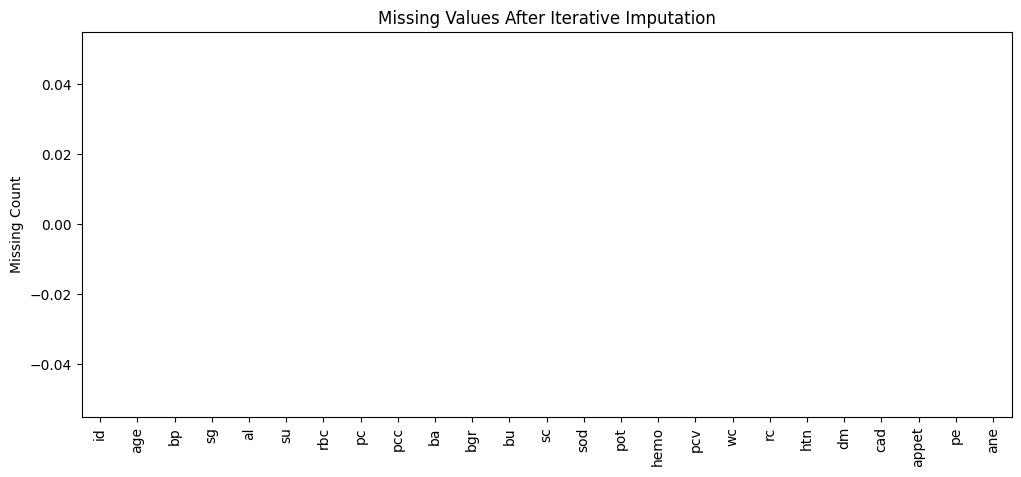

In [29]:
plt.figure(figsize=(12,5))


missing_after.plot(
    kind="bar"
)


plt.title(
    "Missing Values After Iterative Imputation"
)


plt.ylabel(
    "Missing Count"
)


plt.xticks(
    rotation=90
)


plt.show()

In [30]:
from sklearn.ensemble import IsolationForest



iso = IsolationForest(

    contamination="auto",

    random_state=SEED,

    n_estimators=300

)



outlier_labels = iso.fit_predict(
    X_train_imputed
)



outlier_labels[:10]

array([ 1, -1,  1, -1, -1,  1,  1,  1,  1,  1])

In [31]:
outlier_count = np.sum(
    outlier_labels==-1
)


total_samples=len(
    outlier_labels
)


outlier_percentage = (
    outlier_count/
    total_samples
)*100



print(
    "Detected Outliers:",
    outlier_count
)


print(
    "Percentage:",
    round(outlier_percentage,2),
    "%"
)

Detected Outliers: 45
Percentage: 14.06 %


In [32]:
# Keep only normal samples


normal_indices = (
    outlier_labels==1
)



X_train_clean = (
    X_train_imputed[
        normal_indices
    ]
)



y_train_clean = (
    y_train.iloc[
        np.where(normal_indices)[0]
    ]
)



print(
    "Before:",
    X_train_imputed.shape
)


print(
    "After:",
    X_train_clean.shape
)

Before: (320, 25)
After: (275, 25)


In [33]:
print(
"Training Data:",
X_train_clean.shape
)

print(
"Testing Data:",
X_test_imputed.shape
)

print(
"Target:",
y_train_clean.shape
)

Training Data: (275, 25)
Testing Data: (80, 25)
Target: (275,)


In [34]:
# =====================================
# Feature Selection Dataset
# =====================================


X_fs = X_train_clean.copy()

y_fs = y_train_clean.copy()



print(
    X_fs.shape
)


print(
    y_fs.shape
)

(275, 25)
(275,)


In [35]:
from boruta import BorutaPy

from sklearn.ensemble import RandomForestClassifier

# =====================================
# Boruta Base Estimator
# =====================================


rf_selector = RandomForestClassifier(

    n_estimators=500,

    random_state=SEED,

    class_weight="balanced",

    n_jobs=-1

)



rf_selector
# =====================================
# Boruta Feature Selection
# =====================================


boruta_selector = BorutaPy(

    estimator=rf_selector,

    n_estimators="auto",

    max_iter=100,

    random_state=SEED,

    verbose=1

)



boruta_selector.fit(

    X_fs.values,

    y_fs.values

)

# =====================================
# Boruta Decision
# =====================================


boruta_results = pd.DataFrame({

    "Feature":
    X_fs.columns,


    "Ranking":
    boruta_selector.ranking_,


    "Selected":
    boruta_selector.support_

})



boruta_results.sort_values(
    "Ranking"
)
# Confirmed features

boruta_features = (

    X_fs.columns[
        boruta_selector.support_
    ]

    .tolist()

)


print(
"Boruta Selected Features:"
)


print(
boruta_features
)


print(
"Number:",
len(boruta_features)
)

Iteration: 1 / 100
Iteration: 2 / 100
Iteration: 3 / 100
Iteration: 4 / 100
Iteration: 5 / 100
Iteration: 6 / 100
Iteration: 7 / 100
Iteration: 8 / 100
Iteration: 9 / 100
Iteration: 10 / 100
Iteration: 11 / 100
Iteration: 12 / 100
Iteration: 13 / 100
Iteration: 14 / 100
Iteration: 15 / 100
Iteration: 16 / 100
Iteration: 17 / 100
Iteration: 18 / 100
Iteration: 19 / 100
Iteration: 20 / 100
Iteration: 21 / 100
Iteration: 22 / 100
Iteration: 23 / 100
Iteration: 24 / 100
Iteration: 25 / 100
Iteration: 26 / 100
Iteration: 27 / 100
Iteration: 28 / 100
Iteration: 29 / 100
Iteration: 30 / 100
Iteration: 31 / 100
Iteration: 32 / 100
Iteration: 33 / 100
Iteration: 34 / 100
Iteration: 35 / 100
Iteration: 36 / 100
Iteration: 37 / 100
Iteration: 38 / 100
Iteration: 39 / 100
Iteration: 40 / 100
Iteration: 41 / 100
Iteration: 42 / 100
Iteration: 43 / 100
Iteration: 44 / 100
Iteration: 45 / 100
Iteration: 46 / 100
Iteration: 47 / 100
Iteration: 48 / 100
Iteration: 49 / 100
Iteration: 50 / 100
Iteration

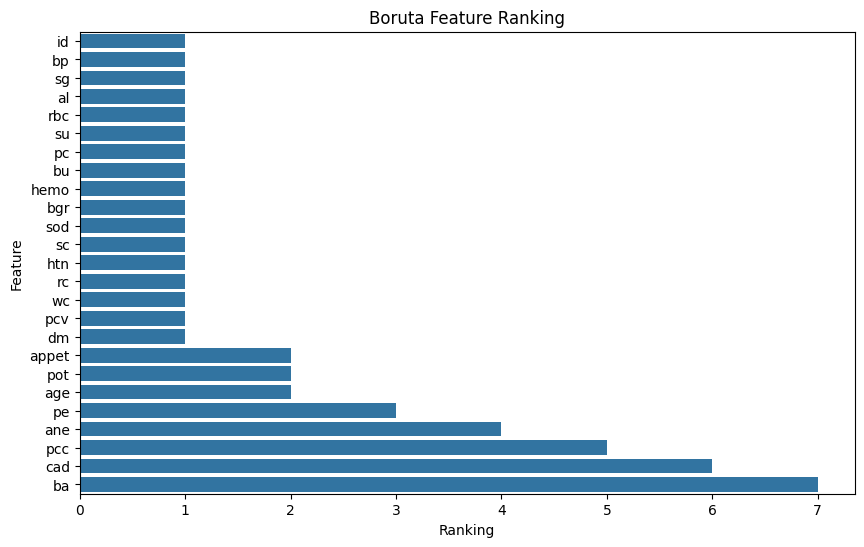

In [36]:
plt.figure(figsize=(10,6))


sns.barplot(

    data=boruta_results.sort_values(
        "Ranking"
    ),

    x="Ranking",

    y="Feature"

)



plt.title(
    "Boruta Feature Ranking"
)


plt.show()

In [37]:
X_train_boruta = X_train_clean[
    boruta_features
]


X_test_boruta = X_test_imputed[
    boruta_features
]


print(
X_train_boruta.shape
)

(275, 17)


In [38]:
import shap


# Temporary model for SHAP

shap_model = RandomForestClassifier(

    n_estimators=500,

    random_state=SEED,

    class_weight="balanced"

)



shap_model.fit(

    X_train_boruta,

    y_train_clean

)


print(
"SHAP model trained"
)

SHAP model trained


In [39]:
# =====================================
# SHAP Tree Explainer
# =====================================


explainer = shap.TreeExplainer(
    shap_model
)


shap_values = explainer.shap_values(
    X_train_boruta
)



print(
"SHAP values generated"
)

SHAP values generated


In [43]:
# =====================================
# Correct Mean Absolute SHAP Importance
# =====================================

import pandas as pd
import numpy as np


# Convert SHAP output to numpy
shap_array = np.array(shap_values)


print("Original SHAP shape:", shap_array.shape)


# Handle different SHAP output formats

if len(shap_array.shape) == 3:
    # New SHAP format: (samples, features, classes)
    shap_matrix = shap_array[:, :, 1]

elif len(shap_array.shape) == 2:
    # Already matrix format
    shap_matrix = shap_array

elif isinstance(shap_values, list):
    # Old SHAP format
    shap_matrix = shap_values[1]

else:
    raise ValueError("Unknown SHAP format")


print("Processed SHAP shape:", shap_matrix.shape)


# Use matching feature names

if shap_matrix.shape[1] == len(X_train_boruta.columns):
    
    feature_names = X_train_boruta.columns

elif shap_matrix.shape[1] == len(X_train_encoded.columns):
    
    feature_names = X_train_encoded.columns

else:
    raise ValueError(
        f"Feature mismatch: SHAP has {shap_matrix.shape[1]} features "
        "but dataset columns do not match."
    )


# Create importance dataframe

shap_importance = pd.DataFrame({

    "Feature": feature_names,

    "Mean_SHAP": np.abs(
        shap_matrix
    ).mean(axis=0)

})


# Sort importance

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


shap_importance

Original SHAP shape: (275, 17, 2)
Processed SHAP shape: (275, 17)


,Feature,Mean_SHAP
0,id,0.199936
1,hemo,0.089062
2,sg,0.066033
3,sc,0.040506
4,al,0.035604
5,rbc,0.034350
6,htn,0.015840
7,pcv,0.014382
8,rc,0.011922
9,dm,0.007378


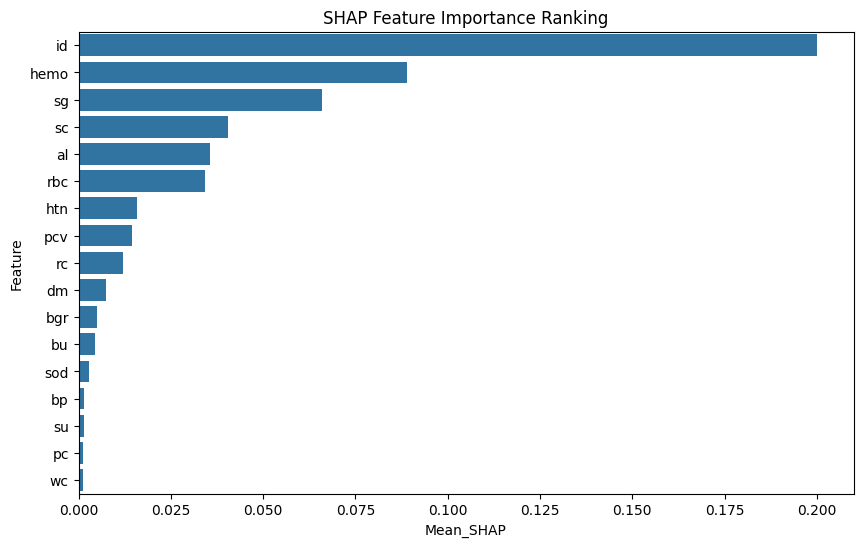

In [44]:
plt.figure(figsize=(10,6))


sns.barplot(

    data=shap_importance,

    x="Mean_SHAP",

    y="Feature"

)



plt.title(
    "SHAP Feature Importance Ranking"
)


plt.show()

In [45]:
# =====================================
# Select final features
# =====================================


TOP_K = min(
    15,
    len(shap_importance)
)



final_features = (

    shap_importance
    .head(TOP_K)
    ["Feature"]
    .tolist()

)



print(
"Final Selected Features:"
)


for f in final_features:
    print("-",f)



print(
"\nTotal Features:",
len(final_features)
)

Final Selected Features:
- id
- hemo
- sg
- sc
- al
- rbc
- htn
- pcv
- rc
- dm
- bgr
- bu
- sod
- bp
- su

Total Features: 15


In [46]:
# =====================================
# Final Dataset
# =====================================


X_train_final = (
    X_train_boruta[
        final_features
    ]
)


X_test_final = (
    X_test_boruta[
        final_features
    ]
)



print(
"Final Training Shape:",
X_train_final.shape
)


print(
"Final Testing Shape:",
X_test_final.shape
)

Final Training Shape: (275, 15)
Final Testing Shape: (80, 15)


In [47]:
# Save ranking tables

boruta_results.to_csv(
    "boruta_feature_results.csv",
    index=False
)


shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)



print(
"Feature selection files saved"
)

Feature selection files saved


In [48]:
# =====================================
# Model Imports
# =====================================


import time


# Boosting models

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier



# Tree models

from sklearn.ensemble import (

    RandomForestClassifier,

    ExtraTreesClassifier,

    HistGradientBoostingClassifier

)



# Metrics

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    cohen_kappa_score,

    brier_score_loss,

    confusion_matrix

)



print(
"Model libraries imported"
)

Model libraries imported


In [50]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_prob
):


    cm = confusion_matrix(
        y_true,
        y_pred
    )


    TN, FP, FN, TP = cm.ravel()



    results={

        "Model":model_name,


        "Accuracy":
        accuracy_score(
            y_true,
            y_pred
        ),


        "Precision":
        precision_score(
            y_true,
            y_pred
        ),


        "Recall":
        recall_score(
            y_true,
            y_pred
        ),


        "F1":
        f1_score(
            y_true,
            y_pred
        ),


        "AUC":
        roc_auc_score(
            y_true,
            y_prob
        ),


        "Specificity":
        TN/(TN+FP),


        "FPR":
        FP/(FP+TN),


        "FNR":
        FN/(FN+TP),


        "Kappa":
        cohen_kappa_score(
            y_true,
            y_pred
        ),


        "Brier":
        brier_score_loss(
            y_true,
            y_prob
        )

    }


    return results

In [52]:
models={}

results=[]

prediction_probabilities={}

prediction_labels={}

In [54]:
start=time.time()


xgb_model=XGBClassifier(

    n_estimators=300,

    learning_rate=0.03,

    max_depth=4,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=SEED,

    eval_metric="logloss"

)


xgb_model.fit(

    X_train_final,

    y_train_clean

)


train_time=time.time()-start



models["XGBoost"]=xgb_model


print(
"Training time:",
train_time
)
prob=xgb_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities["XGBoost"]=prob

prediction_labels["XGBoost"]=pred



results.append(
evaluate_model(
    "XGBoost",
    y_test,
    pred,
    prob
)
)


Training time: 0.0656898021697998


In [55]:
start=time.time()


cat_model=CatBoostClassifier(

    iterations=300,

    depth=5,

    learning_rate=0.03,

    random_seed=SEED,

    verbose=0

)



cat_model.fit(

    X_train_final,

    y_train_clean

)



models["CatBoost"]=cat_model


print(
"CatBoost completed"
)

prob=cat_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)


prediction_probabilities["CatBoost"]=prob

prediction_labels["CatBoost"]=pred



results.append(

evaluate_model(
    "CatBoost",
    y_test,
    pred,
    prob
)

)

CatBoost completed


In [56]:
lgb_model=LGBMClassifier(

    n_estimators=300,

    learning_rate=0.03,

    max_depth=5,

    random_state=SEED

)


lgb_model.fit(

    X_train_final,

    y_train_clean

)



models["LightGBM"]=lgb_model

prob=lgb_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities["LightGBM"]=prob

prediction_labels["LightGBM"]=pred



results.append(

evaluate_model(
    "LightGBM",
    y_test,
    pred,
    prob
)

)

[LightGBM] [Info] Number of positive: 155, number of negative: 120
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 501
[LightGBM] [Info] Number of data points in the train set: 275, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.563636 -> initscore=0.255933
[LightGBM] [Info] Start training from score 0.255933
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [57]:
rf_model=RandomForestClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=SEED,

    n_jobs=-1

)



rf_model.fit(

    X_train_final,

    y_train_clean

)



models["Random Forest"]=rf_model

prob=rf_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)


prediction_probabilities["Random Forest"]=prob

prediction_labels["Random Forest"]=pred



results.append(

evaluate_model(
    "Random Forest",
    y_test,
    pred,
    prob
)

)

In [58]:
extra_model=ExtraTreesClassifier(

    n_estimators=500,

    class_weight="balanced",

    random_state=SEED,

    n_jobs=-1

)



extra_model.fit(

    X_train_final,

    y_train_clean

)



models["Extra Trees"]=extra_model

prob=extra_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities["Extra Trees"]=prob

prediction_labels["Extra Trees"]=pred



results.append(

evaluate_model(
    "Extra Trees",
    y_test,
    pred,
    prob
)

)

In [59]:
hist_model=HistGradientBoostingClassifier(

    learning_rate=0.05,

    max_iter=300,

    random_state=SEED

)



hist_model.fit(

    X_train_final,

    y_train_clean

)



models["HistGradientBoosting"]=hist_model
prob=hist_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)


prediction_probabilities["HistGradientBoosting"]=prob

prediction_labels["HistGradientBoosting"]=pred



results.append(

evaluate_model(
    "HistGradientBoosting",
    y_test,
    pred,
    prob
)

)


In [60]:
from interpret.glassbox import ExplainableBoostingClassifier


ebm_model=ExplainableBoostingClassifier(

    random_state=SEED

)


ebm_model.fit(

    X_train_final,

    y_train_clean

)



models["EBM"]=ebm_model
prob=ebm_model.predict_proba(
    X_test_final
)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities["EBM"]=prob

prediction_labels["EBM"]=pred



results.append(

evaluate_model(
    "EBM",
    y_test,
    pred,
    prob
)

)


In [61]:
try:

    from tabpfn import TabPFNClassifier


    tabpfn_model=TabPFNClassifier(

        device="auto"

    )


    tabpfn_model.fit(

        X_train_final.values,

        y_train_clean.values

    )


    models["TabPFN"]=tabpfn_model


    print(
        "TabPFN trained"
    )


except Exception as e:

    print(
        "TabPFN unavailable:",
        e
    )

if "TabPFN" in models:


    prob=models["TabPFN"].predict_proba(

        X_test_final.values

    )[:,1]


    pred=(prob>=0.5).astype(int)



    prediction_probabilities["TabPFN"]=prob

    prediction_labels["TabPFN"]=pred



    results.append(

    evaluate_model(
        "TabPFN",
        y_test,
        pred,
        prob
    )

    )
    

TabPFN unavailable: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open https://ux.priorlabs.ai in a browser and log in (or register)
  2. Accept the license on the Licenses tab
  3. Copy your API Key from https://ux.priorlabs.ai/account
  4. Set the environment variable: export TABPFN_TOKEN="<your-api-key>"
     or in Python (before calling .fit()): import os; os.environ["TABPFN_TOKEN"] = "<your-api-key>"


In [62]:
individual_results=pd.DataFrame(
    results
)


individual_results.sort_values(

    "AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,FPR,FNR,Kappa,Brier
0,XGBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,7.953508e-05
1,XGBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,7.953508e-05
2,CatBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,3.494051e-04
4,Random Forest,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.049100e-03
7,EBM,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,8.335950e-09
5,Extra Trees,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.426100e-03
6,HistGradientBoosting,0.9875,1.0,0.98,0.989899,0.990000,1.0,0.0,0.02,0.97351,1.249980e-02
3,LightGBM,0.9875,1.0,0.98,0.989899,0.983333,1.0,0.0,0.02,0.97351,1.249829e-02


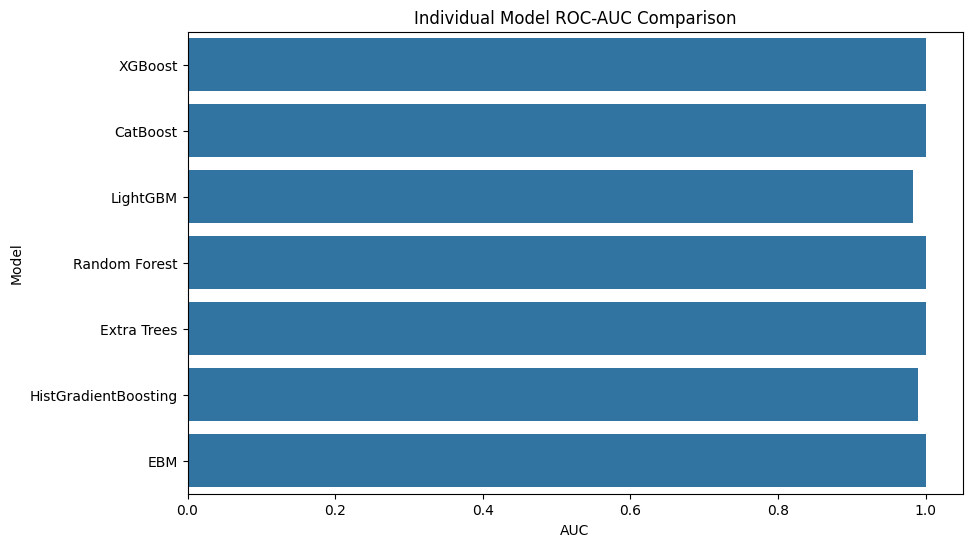

In [63]:
plt.figure(figsize=(10,6))


sns.barplot(

    data=individual_results,

    x="AUC",

    y="Model"

)


plt.title(
"Individual Model ROC-AUC Comparison"
)


plt.show()

In [64]:
from sklearn.ensemble import (

    StackingClassifier,

    VotingClassifier

)


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import roc_auc_score


print(
"Ensemble libraries loaded"
)

Ensemble libraries loaded


In [65]:
base_estimators=[

    (
        "xgb",
        models["XGBoost"]
    ),


    (
        "cat",
        models["CatBoost"]
    ),


    (
        "lgb",
        models["LightGBM"]
    ),


    (
        "extra",
        models["Extra Trees"]
    )

]


print(
"Base learners prepared"
)

Base learners prepared


In [66]:
stacking_model = StackingClassifier(

    estimators=base_estimators,


    final_estimator=LogisticRegression(

        max_iter=1000,

        random_state=SEED

    ),


    stack_method="predict_proba",

    cv=5,

    n_jobs=-1

)



stacking_model.fit(

    X_train_final,

    y_train_clean

)



models["Stacking Ensemble"]=stacking_model



print(
"Stacking model trained"
)

prob = stacking_model.predict_proba(

    X_test_final

)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities[
    "Stacking Ensemble"
]=prob


prediction_labels[
    "Stacking Ensemble"
]=pred



results.append(

evaluate_model(

    "Stacking Ensemble",

    y_test,

    pred,

    prob

)

)




[LightGBM] [Info] Number of positive: 155, number of negative: 120
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 501
[LightGBM] [Info] Number of data points in the train set: 275, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.563636 -> initscore=0.255933
[LightGBM] [Info] Start training from score 0.255933
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [67]:
soft_voting_model = VotingClassifier(

    estimators=base_estimators,


    voting="soft",

    n_jobs=-1

)



soft_voting_model.fit(

    X_train_final,

    y_train_clean

)



models["Soft Voting"]=soft_voting_model



print(
"Soft voting trained"
)


prob=soft_voting_model.predict_proba(

    X_test_final

)[:,1]


pred=(prob>=0.5).astype(int)



prediction_probabilities[
    "Soft Voting"
]=prob


prediction_labels[
    "Soft Voting"
]=pred



results.append(

evaluate_model(

    "Soft Voting",

    y_test,

    pred,

    prob

)

)




[LightGBM] [Info] Number of positive: 155, number of negative: 120
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 501
[LightGBM] [Info] Number of data points in the train set: 275, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.563636 -> initscore=0.255933
[LightGBM] [Info] Start training from score 0.255933
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [68]:
# Individual AUC scores


auc_weights={}



for name,prob in prediction_probabilities.items():


    if name in [
        "XGBoost",
        "CatBoost",
        "LightGBM",
        "Extra Trees"
    ]:


        auc_weights[name]=roc_auc_score(

            y_test,

            prob

        )



auc_weights




{'XGBoost': np.float64(1.0),
 'CatBoost': np.float64(1.0),
 'LightGBM': np.float64(0.9833333333333333),
 'Extra Trees': np.float64(1.0)}

In [69]:
total=sum(
    auc_weights.values()
)


normalized_weights={

    k:v/total

    for k,v in auc_weights.items()

}



normalized_weights

{'XGBoost': np.float64(0.2510460251046025),
 'CatBoost': np.float64(0.2510460251046025),
 'LightGBM': np.float64(0.24686192468619245),
 'Extra Trees': np.float64(0.2510460251046025)}

In [70]:
weighted_probability=np.zeros(

    len(X_test_final)

)



for model_name,weight in normalized_weights.items():


    weighted_probability += (

        prediction_probabilities[model_name]

        *

        weight

    )



weighted_prediction=(

    weighted_probability>=0.5

).astype(int)



prediction_probabilities[
    "Weighted Voting"
]=weighted_probability


prediction_labels[
    "Weighted Voting"
]=weighted_prediction



results.append(

evaluate_model(

    "Weighted Voting",

    y_test,

    weighted_prediction,

    weighted_probability

)

)



print(
"Weighted voting completed"
)

Weighted voting completed


In [71]:
ensemble_results=pd.DataFrame(
    results
)


ensemble_results.sort_values(

    "AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,AUC,Specificity,FPR,FNR,Kappa,Brier
0,XGBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,7.953508e-05
1,XGBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,7.953508e-05
2,CatBoost,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,3.494051e-04
4,Random Forest,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.049100e-03
5,Extra Trees,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.426100e-03
8,Stacking Ensemble,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,5.113334e-04
7,EBM,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,8.335950e-09
9,Soft Voting,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.255872e-03
10,Weighted Voting,1.0000,1.0,1.00,1.000000,1.000000,1.0,0.0,0.00,1.00000,1.234923e-03
6,HistGradientBoosting,0.9875,1.0,0.98,0.989899,0.990000,1.0,0.0,0.02,0.97351,1.249980e-02


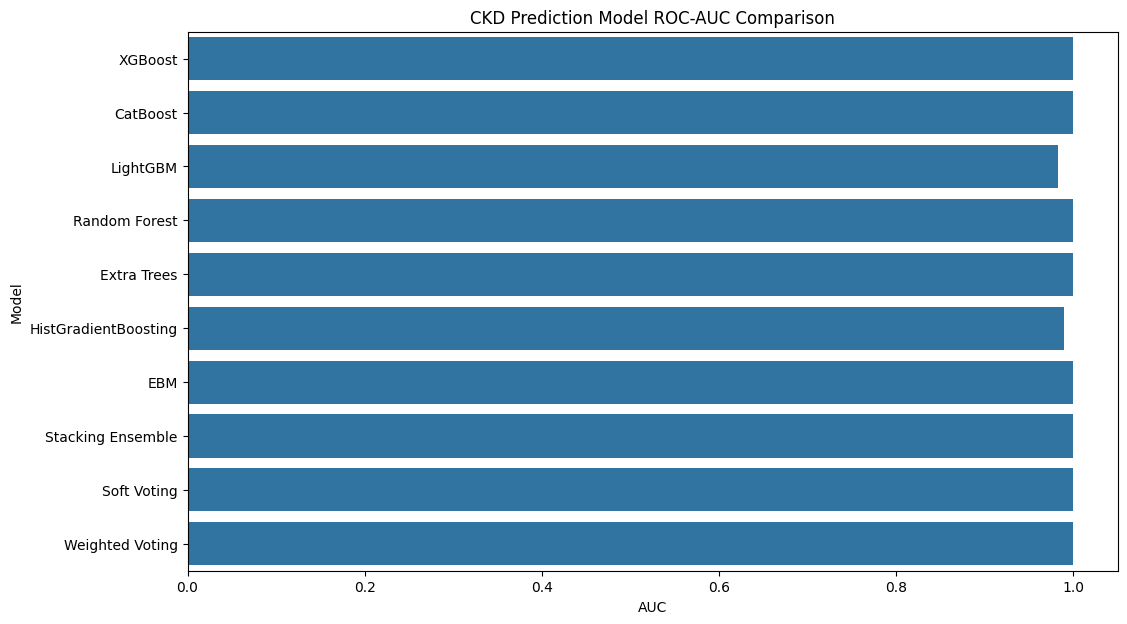

In [72]:
plt.figure(figsize=(12,7))


sns.barplot(

    data=ensemble_results,

    x="AUC",

    y="Model"

)


plt.title(

"CKD Prediction Model ROC-AUC Comparison"

)


plt.show()

In [73]:
ensemble_results.to_csv(

    "CKD_model_performance_results.csv",

    index=False

)


print(
"Performance table saved"
)

Performance table saved


In [74]:
best_model_name=(

    ensemble_results

    .sort_values(
        "AUC",
        ascending=False
    )

    .iloc[0]["Model"]

)



print(

"Current Best Model:",

best_model_name

)

Current Best Model: XGBoost

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -